# 1. Library imports

In [1]:
import os
from functools import partial

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import kstest, skew, kurtosis

from volatility_pipeline.models import GARCHModel, LSTMVolatilityModel, LSTMHybridModel
from volatility_pipeline.evaluation import (
    RollingEvaluator,
    ForecastResult,
    garman_klass,
    parkinson,
    squared_returns,
)


# 2. Configuration

In [2]:
# ── Input data ───────────────────────────────────────────────────────────────
TICKER          = "BZ=F"
FULL_DATA_START = "2010-01-01"
FULL_DATA_END   = "2026-05-31"

TRAIN_START = FULL_DATA_START
TRAIN_END   = "2022-06-30"
TEST_START  = "2022-07-01"

# Shrunk test window for fast LSTM iteration/debugging (~6 months).
# Set TEST_END = FULL_DATA_END for a full-length evaluation once the
# model/config is validated.
TEST_END    = "2022-12-31"

# ── Out-of-sample evaluation (shared) ─────────────────────────────────────────
N_AHEAD     = 1   # forecast horizon; only 1 is currently supported
REFIT_EVERY = 10  # re-estimate parameters every N test steps
WINDOW_TYPE = "expanding"  # 'expanding' | 'sliding'

# VARIANCE_PROXY controls the realized-variance proxy used as the forecast target:
#   "garman_klass"  — Garman-Klass (1980): uses OHLC; 5-8x less noisy than r^2
#   "parkinson"     — Parkinson (1980): uses High/Low only; simpler than GK
#   "squared"       — r^2: noisiest, reduces DM/MCS power significantly
VARIANCE_PROXY = "garman_klass"  # 'garman_klass' | 'parkinson' | 'squared'

RANDOM_SEED = 42

# ── GARCH baseline(s) for hybrid LSTM ─────────────────────────────────────────
# Only the (model_type, dist) combinations referenced by LSTM_HYBRID_SPECS below
# are fitted, used as the hybrid base model and as a reference in the residual
# decomposition plots.
GARCH_SPECS = [
    ("GARCH", "normal"),
]

# ── LSTM — standalone & hybrid ────────────────────────────────────────────────
LSTM_LOOKBACK      = 20
LSTM_HIDDEN_SIZE   = 32
LSTM_NUM_LAYERS    = 1
LSTM_DROPOUT       = 0.2
LSTM_LR            = 1e-3
LSTM_MAX_EPOCHS    = 100
LSTM_PATIENCE      = 10
LSTM_BATCH_SIZE    = 32
LSTM_VAL_FRACTION  = 0.15
LSTM_WINSOR_LIMITS = (0.01, 0.01)
LSTM_DEVICE        = None  # None -> auto-select (cuda > mps > cpu)

# Hybrid LSTM specifications: (garch_model_type, garch_dist, mode)
# mode 'features' : GARCH one-step forecast appended as an input feature/channel
# mode 'residual' : final forecast = GARCH_forecast + LSTM_residual_correction
LSTM_HYBRID_SPECS = [
    ("GARCH", "normal", "features"),
    ("GARCH", "normal", "residual"),
]

# Models run sequentially: MPS/CUDA hold a single device context, so
# RollingEvaluator(n_jobs=1) is required for LSTM model factories.
LSTM_PARALLEL_JOBS = 1

print(f"Test period: {TEST_START} → {TEST_END}  |  CPUs available: {os.cpu_count()}")


Test period: 2022-07-01 → 2022-12-31  |  CPUs available: 10


# 3. Data

In [3]:
# Import OHLC data from Yahoo Finance (needed for range-based variance proxies)
data   = yf.download(TICKER, start=FULL_DATA_START, end=FULL_DATA_END)
close  = data["Close"].squeeze()
open_  = data["Open"].squeeze()
high   = data["High"].squeeze()
low    = data["Low"].squeeze()

returns = np.log(close / close.shift(1)).dropna()

# Compute variance proxy on the original DatetimeIndex (before PeriodIndex conversion)
if VARIANCE_PROXY == "garman_klass":
    _proxy = garman_klass(
        open_.reindex(returns.index),
        high.reindex(returns.index),
        low.reindex(returns.index),
        close.reindex(returns.index),
    )
elif VARIANCE_PROXY == "parkinson":
    _proxy = parkinson(
        high.reindex(returns.index),
        low.reindex(returns.index),
    )
else:  # "squared"
    _proxy = squared_returns(returns)

# Convert both series to PeriodIndex for consistency with arch model indexing
returns.index = pd.PeriodIndex(returns.index, freq='D')
_proxy.index  = returns.index
variance_proxy = _proxy

print(f"Proxy: {VARIANCE_PROXY}  |  {len(variance_proxy)} observations")
print(f"  min={variance_proxy.min():.6e}  max={variance_proxy.max():.6e}  mean={variance_proxy.mean():.6e}")


[*********************100%***********************]  1 of 1 completed

Proxy: garman_klass  |  4094 observations
  min=-4.480334e-05  max=6.363584e-02  mean=4.795447e-04


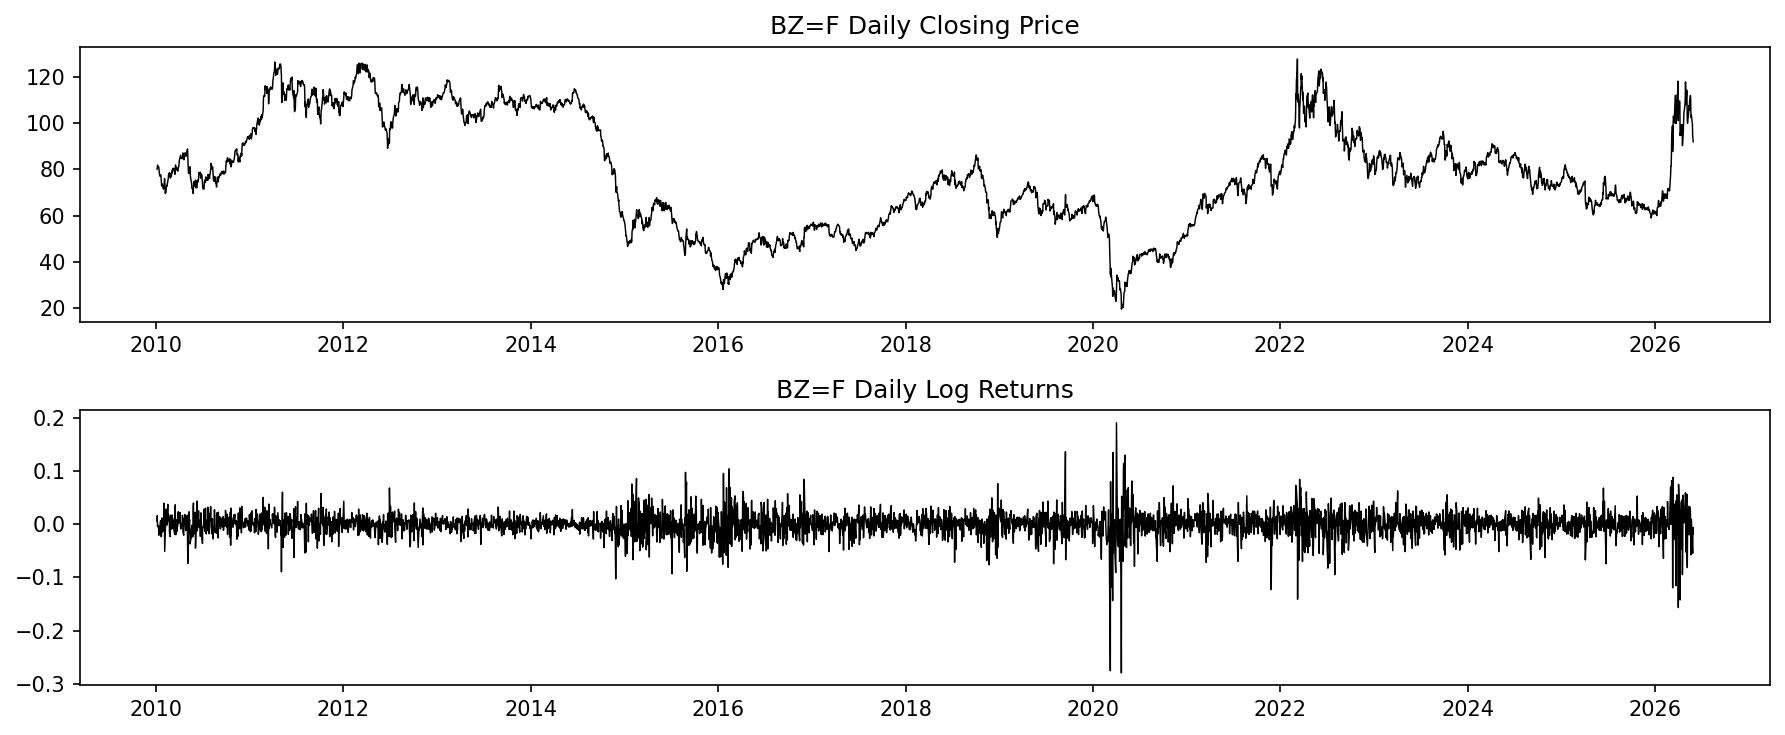

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), dpi=150)
axes[0].plot(close, linewidth=0.7, color='black')
axes[0].set_title(f"{TICKER} Daily Closing Price")
axes[1].plot(returns.index.to_timestamp(), returns.values, linewidth=0.7, color='black')
axes[1].set_title(f"{TICKER} Daily Log Returns")
plt.tight_layout()
plt.show()


In [5]:
train_returns = returns[returns.index <= TRAIN_END]
test_returns  = returns[(returns.index >= TEST_START) & (returns.index <= TEST_END)]

print(f"Train: {train_returns.index[0]}  →  {train_returns.index[-1]}  ({len(train_returns)} obs)")
print(f"Test:  {test_returns.index[0]}  →  {test_returns.index[-1]}  ({len(test_returns)} obs)")


Train: 2010-01-05  →  2022-06-30  (3110 obs)
Test:  2022-07-01  →  2022-12-30  (127 obs)


# 4. GARCH Baselines (for hybrid LSTM)

Fits and evaluates only the GARCH specification(s) referenced by `LSTM_HYBRID_SPECS`,
used as the base model for the hybrid LSTM and as a reference in the residual
decomposition plots below.

In [6]:
evaluator = RollingEvaluator(
    n_ahead=N_AHEAD, refit_every=REFIT_EVERY, window_type=WINDOW_TYPE
)

garch_eval_specs = [
    (partial(GARCHModel, t, d), f"{t}-{d.upper()}")
    for t, d in GARCH_SPECS
]

garch_results: dict[str, ForecastResult] = evaluator.evaluate_many(
    garch_eval_specs, train_returns, test_returns,
    actuals_series=variance_proxy,
    verbose=True, n_jobs=1,
)
print(f"\nCompleted {len(garch_results)} GARCH baseline model(s).")


Evaluating GARCH-NORMAL...
  [GARCH-NORMAL] re-fitted at step 0/127 (expanding)
  [GARCH-NORMAL] re-fitted at step 10/127 (expanding)
  [GARCH-NORMAL] re-fitted at step 20/127 (expanding)
  [GARCH-NORMAL] re-fitted at step 30/127 (expanding)
  [GARCH-NORMAL] re-fitted at step 40/127 (expanding)
  [GARCH-NORMAL] re-fitted at step 50/127 (expanding)
  [GARCH-NORMAL] re-fitted at step 60/127 (expanding)


  [GARCH-NORMAL] re-fitted at step 70/127 (expanding)
  [GARCH-NORMAL] re-fitted at step 80/127 (expanding)
  [GARCH-NORMAL] re-fitted at step 90/127 (expanding)
  [GARCH-NORMAL] re-fitted at step 100/127 (expanding)
  [GARCH-NORMAL] re-fitted at step 110/127 (expanding)
  [GARCH-NORMAL] re-fitted at step 120/127 (expanding)

Completed 1 GARCH baseline model(s).


In [7]:
garch_metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in garch_results.items()})
    .T
    .sort_values("RMSE")
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
garch_metrics_df


,RMSE,MAE,MSE,QLIKE
GARCH-NORMAL,0.000631,0.000355,3.983320e-07,-6.192499


# 5. Standalone LSTM

LSTM trained on a rolling window of `[return, squared_return]` (winsorized, RobustScaler-scaled).
Target: next-step log(squared_return), RobustScaler-scaled, inverse-transformed and exponentiated
back to variance units at forecast time.

## 5.1 Out-of-sample evaluation

In [8]:
lstm_eval_specs = [
    (
        partial(LSTMVolatilityModel,
                lookback=LSTM_LOOKBACK,
                hidden_size=LSTM_HIDDEN_SIZE,
                num_layers=LSTM_NUM_LAYERS,
                dropout=LSTM_DROPOUT,
                lr=LSTM_LR,
                max_epochs=LSTM_MAX_EPOCHS,
                patience=LSTM_PATIENCE,
                batch_size=LSTM_BATCH_SIZE,
                val_fraction=LSTM_VAL_FRACTION,
                winsor_limits=LSTM_WINSOR_LIMITS,
                seed=RANDOM_SEED,
                device=LSTM_DEVICE),
        "LSTM-Standalone",
    )
]

lstm_results: dict[str, ForecastResult] = evaluator.evaluate_many(
    lstm_eval_specs, train_returns, test_returns,
    actuals_series=variance_proxy,
    verbose=True, n_jobs=LSTM_PARALLEL_JOBS,
)
print(f"\nCompleted {len(lstm_results)} standalone LSTM model(s).")


Evaluating LSTM-Standalone...


  [LSTM-Standalone] re-fitted at step 0/127 (expanding)


  [LSTM-Standalone] re-fitted at step 10/127 (expanding)


  [LSTM-Standalone] re-fitted at step 20/127 (expanding)


  [LSTM-Standalone] re-fitted at step 30/127 (expanding)


...

  [LSTM-Standalone] re-fitted at step 80/127 (expanding)


  [LSTM-Standalone] re-fitted at step 90/127 (expanding)


  [LSTM-Standalone] re-fitted at step 100/127 (expanding)


  [LSTM-Standalone] re-fitted at step 110/127 (expanding)


  [LSTM-Standalone] re-fitted at step 120/127 (expanding)

Completed 1 standalone LSTM model(s).


In [9]:
lstm_metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in lstm_results.items()})
    .T
    .sort_values("RMSE")
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
lstm_metrics_df


,RMSE,MAE,MSE,QLIKE
LSTM-Standalone,0.000839,0.000593,7.036008e-07,-2.080835


## 5.2 Forecast vs realized

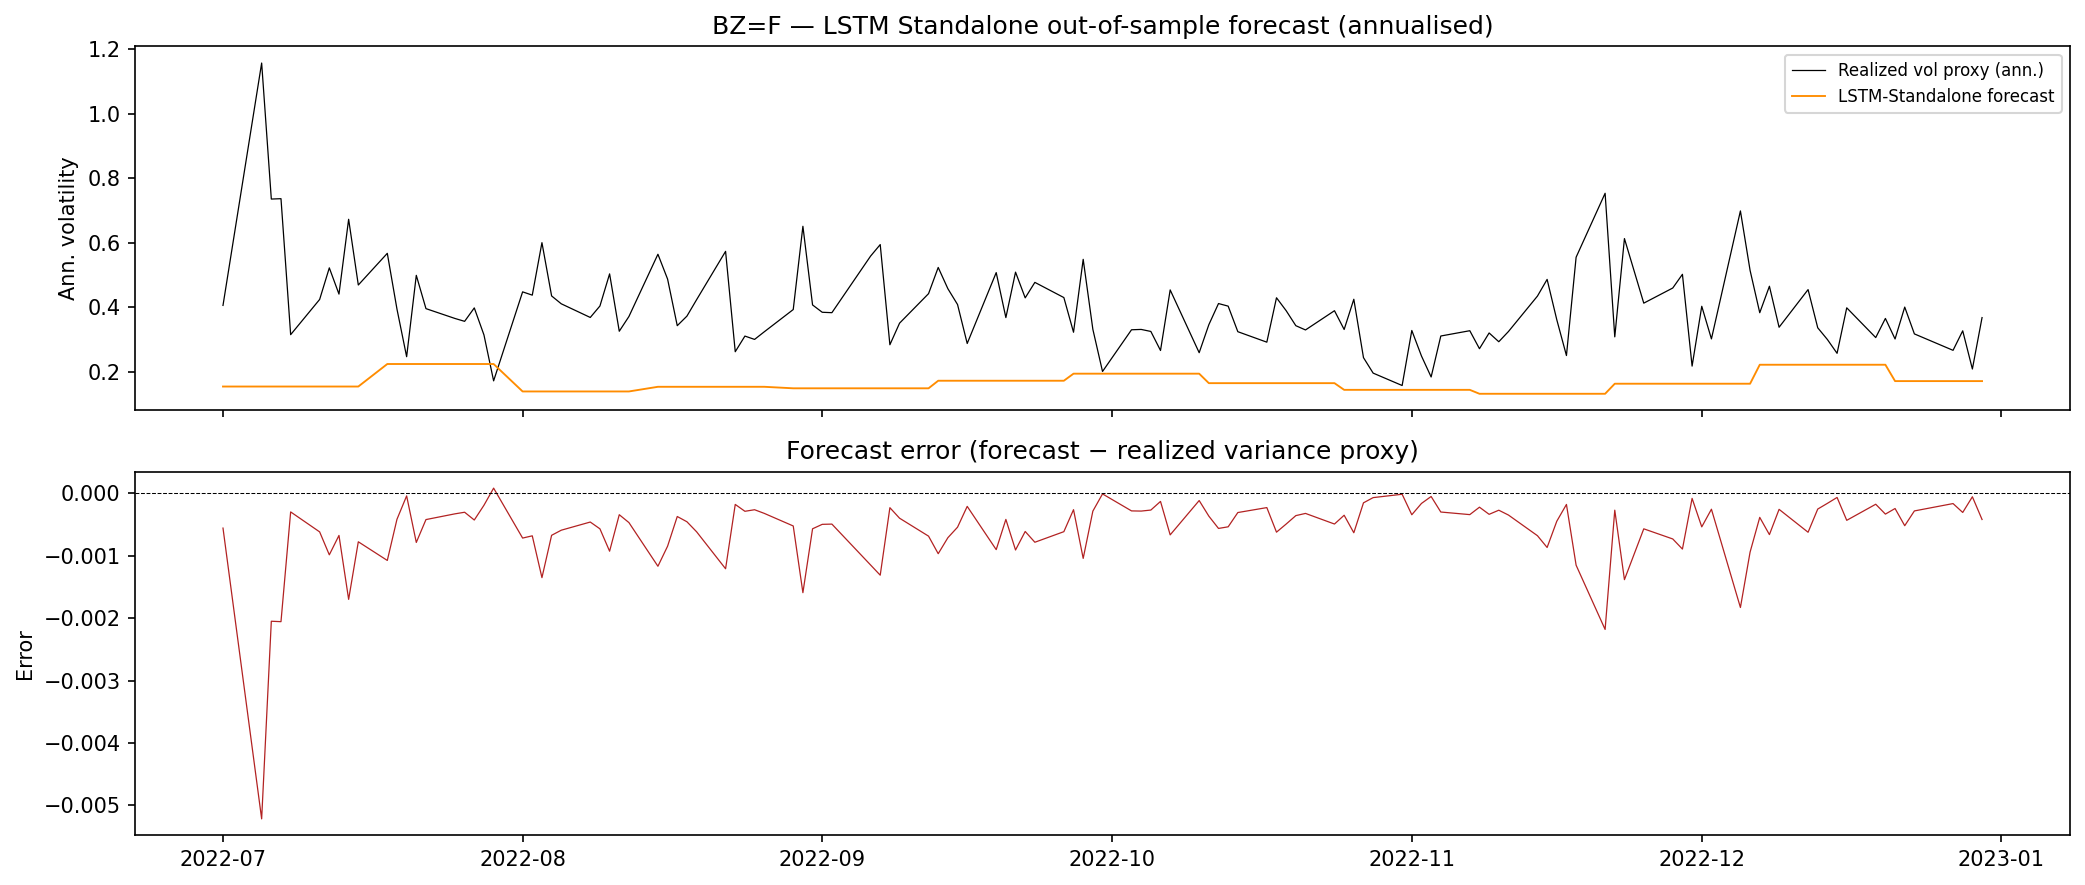

In [10]:
r_lstm = lstm_results["LSTM-Standalone"]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), dpi=150, sharex=True)
axes[0].plot(r_lstm.actuals.index.to_timestamp(), np.sqrt(r_lstm.actuals.values * 252),
              color='black', linewidth=0.6, label='Realized vol proxy (ann.)')
axes[0].plot(r_lstm.forecasts.index.to_timestamp(), np.sqrt(r_lstm.forecasts.values * 252),
              color='darkorange', linewidth=0.9, label='LSTM-Standalone forecast')
axes[0].set_title(f"{TICKER} — LSTM Standalone out-of-sample forecast (annualised)")
axes[0].set_ylabel("Ann. volatility")
axes[0].legend(fontsize=8)
axes[1].plot(r_lstm.errors.index.to_timestamp(), r_lstm.errors.values,
              color='firebrick', linewidth=0.6)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_title("Forecast error (forecast − realized variance proxy)")
axes[1].set_ylabel("Error")
plt.tight_layout()
plt.show()


# 6. Hybrid LSTM

Two hybrid architectures evaluated for each GARCH base model specified in `LSTM_HYBRID_SPECS`:

| Mode | Description |
|------|-------------|
| `features` | LSTM inputs are `[return, squared_return]` plus the GARCH one-step forecast h_{t+1\|t} (log-scaled), broadcast across every timestep of the lookback window. |
| `residual` | **Residual correction**: final forecast = GARCH_forecast + LSTM_residual, where LSTM is trained to predict the GARCH residual (r²_t − h_{t\|t-1}). |

## 6.1 Out-of-sample evaluation

In [11]:
_mode_short = {"features": "feat", "residual": "resid"}

lstm_hybrid_eval_specs = [
    (
        partial(LSTMHybridModel,
                garch_model_type=gt,
                garch_dist=gd,
                mode=m,
                lookback=LSTM_LOOKBACK,
                hidden_size=LSTM_HIDDEN_SIZE,
                num_layers=LSTM_NUM_LAYERS,
                dropout=LSTM_DROPOUT,
                lr=LSTM_LR,
                max_epochs=LSTM_MAX_EPOCHS,
                patience=LSTM_PATIENCE,
                batch_size=LSTM_BATCH_SIZE,
                val_fraction=LSTM_VAL_FRACTION,
                winsor_limits=LSTM_WINSOR_LIMITS,
                seed=RANDOM_SEED,
                device=LSTM_DEVICE),
        f"LSTM-{gt}-{gd.upper()}-{_mode_short[m]}",
    )
    for gt, gd, m in LSTM_HYBRID_SPECS
]

lstm_hybrid_results: dict[str, ForecastResult] = evaluator.evaluate_many(
    lstm_hybrid_eval_specs, train_returns, test_returns,
    actuals_series=variance_proxy,
    verbose=True, n_jobs=LSTM_PARALLEL_JOBS,
)
print(f"\nCompleted {len(lstm_hybrid_results)} hybrid LSTM model(s).")


Evaluating LSTM-GARCH-NORMAL-feat...


  [LSTM-GARCH-NORMAL-feat] re-fitted at step 0/127 (expanding)


  [LSTM-GARCH-NORMAL-feat] re-fitted at step 10/127 (expanding)


  [LSTM-GARCH-NORMAL-feat] re-fitted at step 20/127 (expanding)


  [LSTM-GARCH-NORMAL-feat] re-fitted at step 30/127 (expanding)


...

  [LSTM-GARCH-NORMAL-resid] re-fitted at step 80/127 (expanding)


  [LSTM-GARCH-NORMAL-resid] re-fitted at step 90/127 (expanding)


  [LSTM-GARCH-NORMAL-resid] re-fitted at step 100/127 (expanding)


  [LSTM-GARCH-NORMAL-resid] re-fitted at step 110/127 (expanding)


  [LSTM-GARCH-NORMAL-resid] re-fitted at step 120/127 (expanding)

Completed 2 hybrid LSTM model(s).


In [12]:
lstm_hybrid_metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in lstm_hybrid_results.items()})
    .T
    .sort_values("RMSE")
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
lstm_hybrid_metrics_df


,RMSE,MAE,MSE,QLIKE
LSTM-GARCH-NORMAL-resid,0.000627,0.000347,3.929229e-07,-6.183276
LSTM-GARCH-NORMAL-feat,0.000838,0.000594,7.020894e-07,-2.151420


## 6.2 Residual decomposition (residual-mode hybrids)

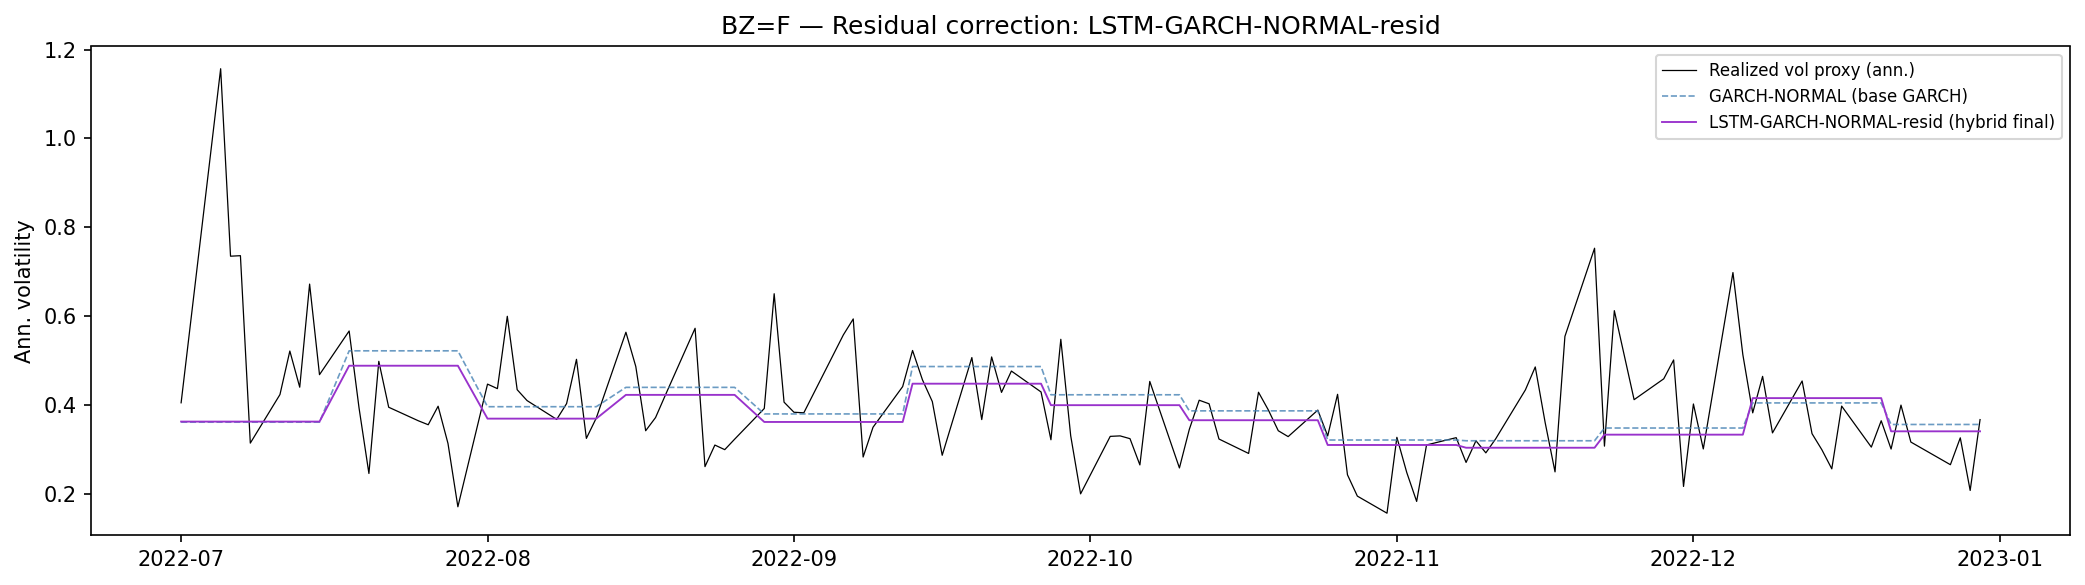

In [13]:
# For each residual-mode hybrid in the results, plot the decomposition:
#   realized variance, GARCH standalone forecast, and final hybrid forecast

resid_names = [name for name in lstm_hybrid_results if name.endswith("-resid")]

for h_name in resid_names:
    # derive base GARCH name from hybrid name, e.g. LSTM-GARCH-NORMAL-resid → GARCH-NORMAL
    parts      = h_name.split("-")  # ['LSTM', 'GARCH', 'NORMAL', 'resid']
    garch_name = "-".join(parts[1:-1])  # 'GARCH-NORMAL'

    r_h  = lstm_hybrid_results[h_name]
    r_g  = garch_results.get(garch_name)

    fig, ax = plt.subplots(figsize=(14, 4), dpi=150)
    ax.plot(r_h.actuals.index.to_timestamp(), np.sqrt(r_h.actuals.values * 252),
            color='black', linewidth=0.6, label='Realized vol proxy (ann.)')
    if r_g is not None:
        ax.plot(r_g.forecasts.index.to_timestamp(), np.sqrt(r_g.forecasts.values * 252),
                color='steelblue', linewidth=0.8, linestyle='--', label=f'{garch_name} (base GARCH)', alpha=0.8)
    ax.plot(r_h.forecasts.index.to_timestamp(), np.sqrt(r_h.forecasts.values * 252),
            color='darkorchid', linewidth=0.9, label=f'{h_name} (hybrid final)')
    ax.set_title(f"{TICKER} — Residual correction: {h_name}")
    ax.set_ylabel("Ann. volatility")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


# 7. Joint Comparison — LSTM models

In [14]:
all_lstm_results: dict[str, ForecastResult] = {
    **garch_results,
    **lstm_results,
    **lstm_hybrid_results,
}

def _group(name: str) -> str:
    if name.startswith("LSTM-") and "-feat" in name:
        return "LSTM Hybrid (features)"
    if name.startswith("LSTM-") and "-resid" in name:
        return "LSTM Hybrid (residual)"
    if name.startswith("LSTM-"):
        return "Standalone LSTM"
    return "GARCH"

all_lstm_metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in all_lstm_results.items()})
    .T
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
all_lstm_metrics_df.insert(0, "Group", all_lstm_metrics_df.index.map(_group))
all_lstm_metrics_df = all_lstm_metrics_df.sort_values(["Group", "RMSE"])
all_lstm_metrics_df


,Group,RMSE,MAE,MSE,QLIKE
GARCH-NORMAL,GARCH,0.000631,0.000355,3.983320e-07,-6.192499
LSTM-GARCH-NORMAL-feat,LSTM Hybrid (features),0.000838,0.000594,7.020894e-07,-2.151420
LSTM-GARCH-NORMAL-resid,LSTM Hybrid (residual),0.000627,0.000347,3.929229e-07,-6.183276
LSTM-Standalone,Standalone LSTM,0.000839,0.000593,7.036008e-07,-2.080835


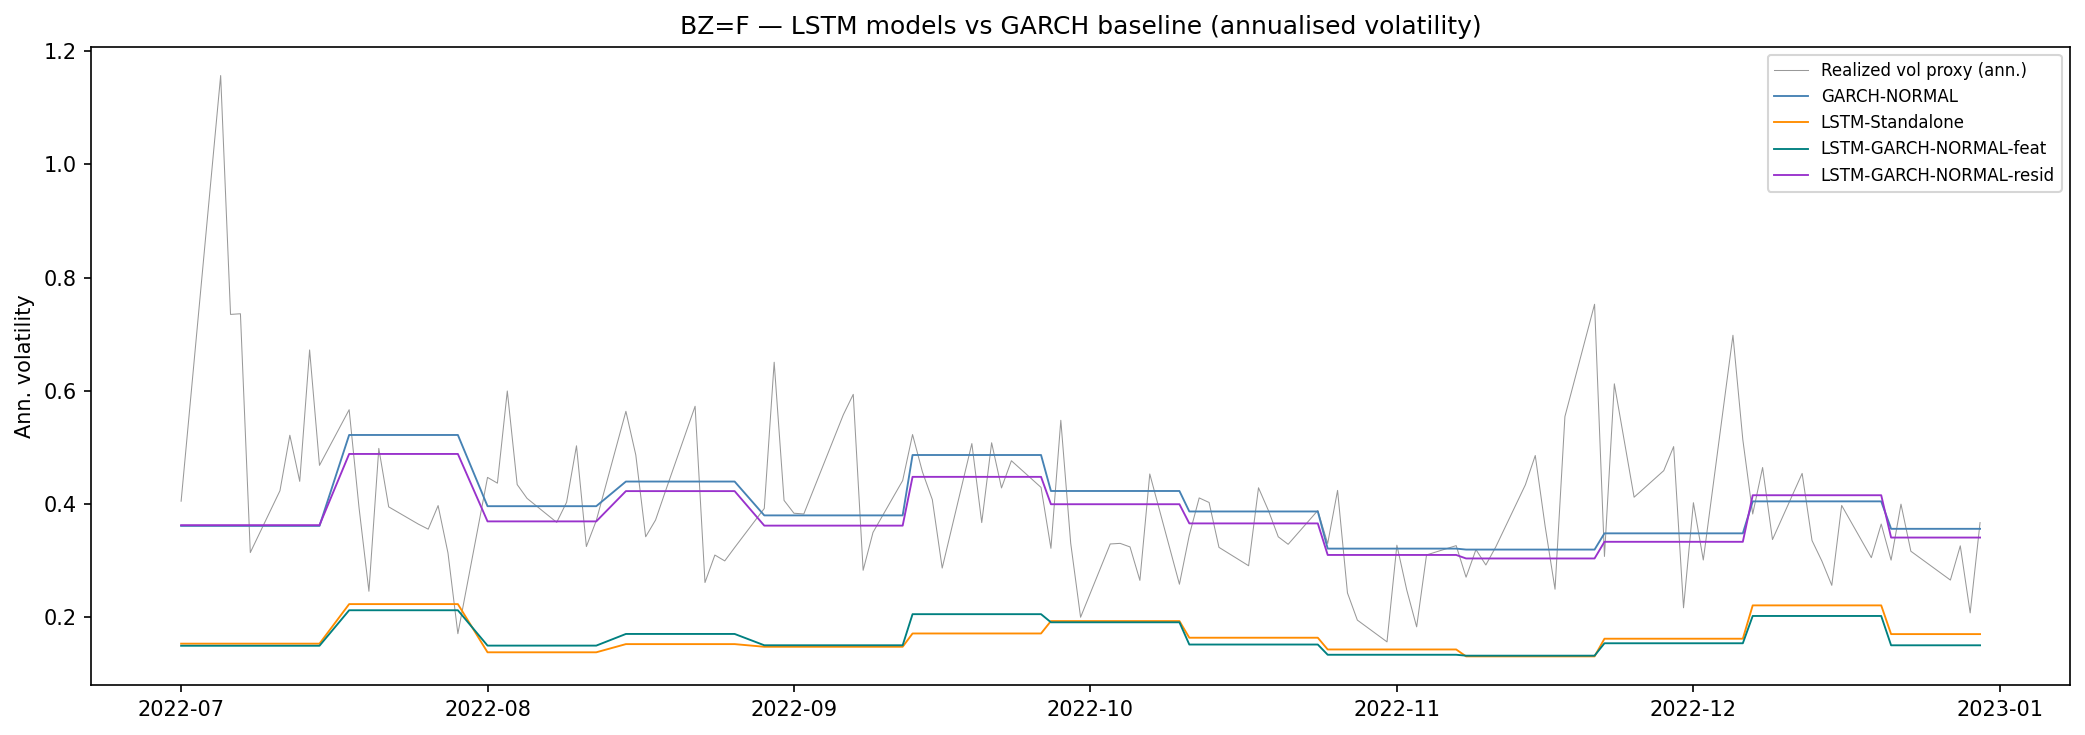

In [15]:
palette = {"GARCH": "steelblue", "Standalone LSTM": "darkorange",
           "LSTM Hybrid (features)": "teal", "LSTM Hybrid (residual)": "darkorchid"}

fig, ax = plt.subplots(figsize=(14, 5), dpi=150)
ref = next(iter(all_lstm_results.values()))
ax.plot(ref.actuals.index.to_timestamp(), np.sqrt(ref.actuals.values * 252),
        color='black', linewidth=0.5, alpha=0.4, label='Realized vol proxy (ann.)')

for name, r in all_lstm_results.items():
    grp = _group(name)
    ax.plot(r.forecasts.index.to_timestamp(), np.sqrt(r.forecasts.values * 252),
            linewidth=0.9, label=name, color=palette.get(grp, 'gray'))

ax.set_title(f"{TICKER} — LSTM models vs GARCH baseline (annualised volatility)")
ax.set_ylabel("Ann. volatility")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
